# Phase 3: Visualizations
In this notebook we create visualizations to communicate key insights 
from the personal finance dataset.

In [4]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 

# Set style for all plots 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data 
df = pd.read_csv('../data/cleaned_finance_data.csv')
monthly = pd.read_csv('../data/monthly_trends.csv')
category_spend = pd.read_csv('../data/category_spend.csv')

print("Data loaded successfully!")
print("Main dataframe shape:", df.shape)

Data loaded successfully!
Main dataframe shape: (1500, 9)


## Chart 1: Total Income vs Expenses

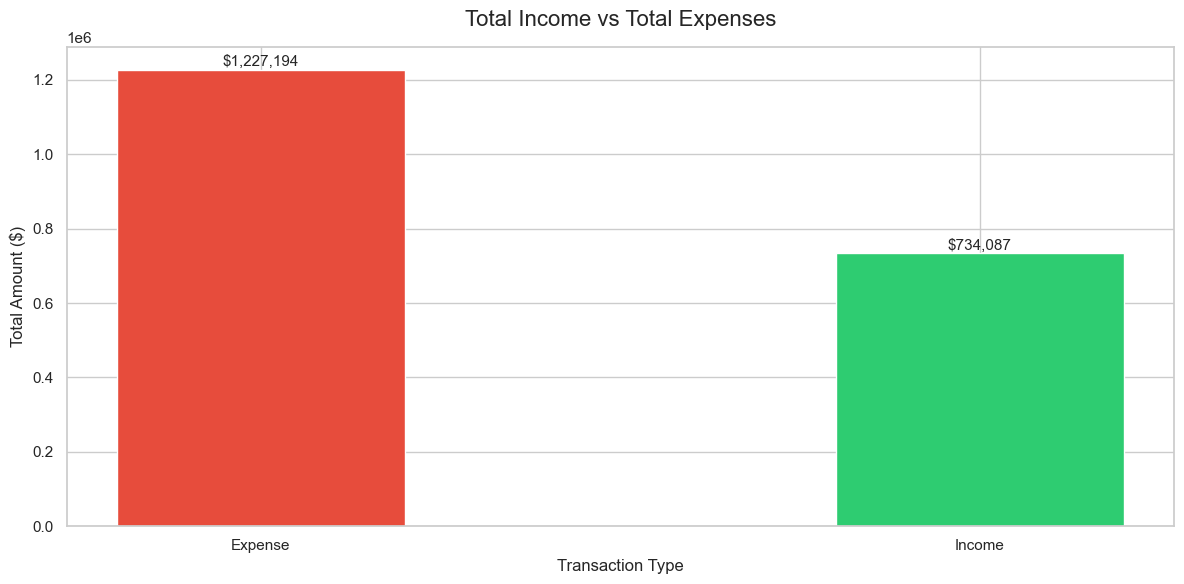

Chart 1 saved!


In [5]:
# Summarise total by type
type_summary = df.groupby('Type')['Amount'].sum().reset_index()

# Plot
fig, ax = plt.subplots()
bars = ax.bar(type_summary['Type'], type_summary['Amount'], 
              color=['#e74c3c', '#2ecc71'], width=0.4)

# Labels
ax.set_title('Total Income vs Total Expenses', fontsize=16, pad=15)
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Total Amount ($)', fontsize=12)

# Add value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/chart1_income_vs_expenses.png', dpi=150)
plt.show()
print("Chart 1 saved!")

## Chart 2: Spending by Category

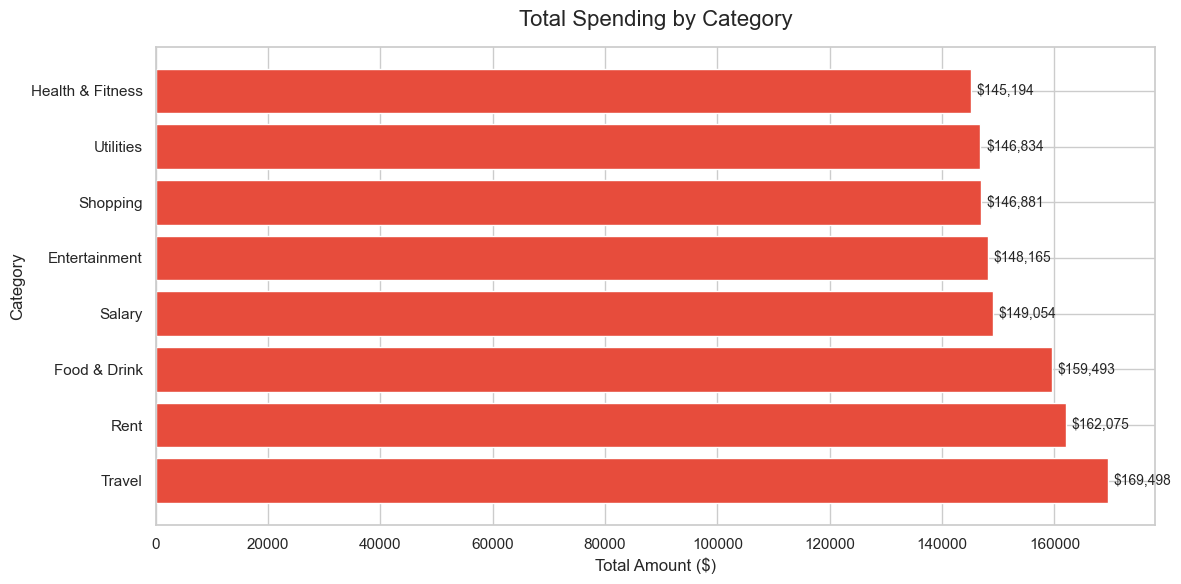

Chart 2 saved!


In [6]:
# Plot
fig, ax = plt.subplots()
bars = ax.barh(category_spend['Category'], category_spend['Total_Spent'],
               color='#e74c3c')

# Labels
ax.set_title('Total Spending by Category', fontsize=16, pad=15)
ax.set_xlabel('Total Amount ($)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart2_spending_by_category.png', dpi=150)
plt.show()
print("Chart 2 saved!")

## Note: Data Quality Observation
Salary appears in the expense category chart due to how the dataset is structured.
Salary is an Income type and will be excluded from expense analysis going forward.

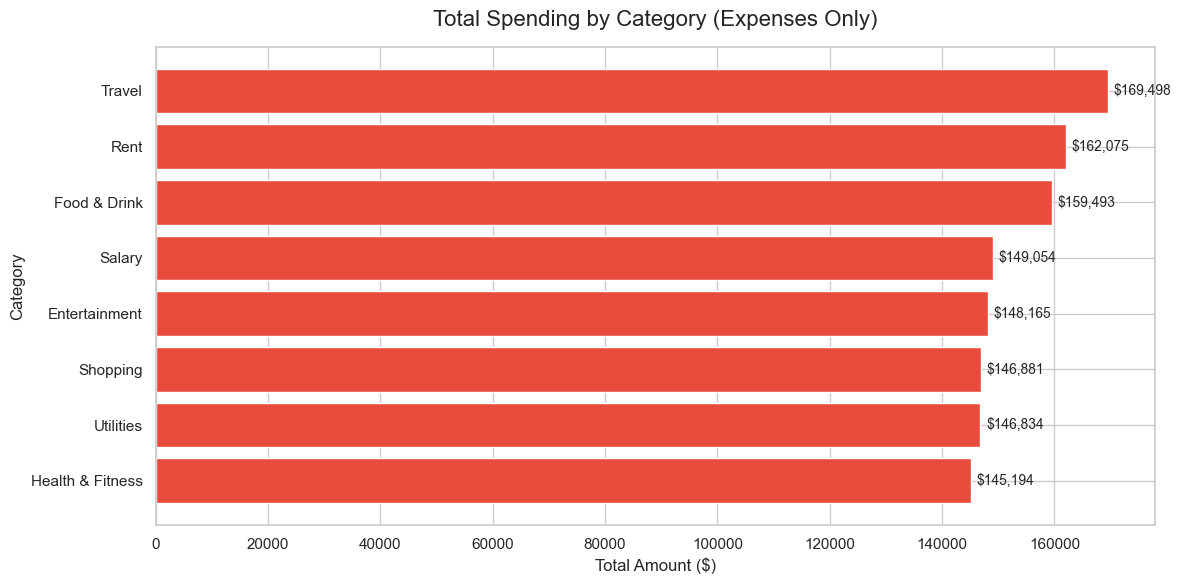

Chart 2 updated and saved!


In [7]:
# Reload category spend excluding income categories
expenses_only = df[df['Type'] == 'Expense']
category_spend_fixed = expenses_only.groupby('Category')['Amount'].sum().reset_index()
category_spend_fixed.columns = ['Category', 'Total_Spent']
category_spend_fixed = category_spend_fixed.sort_values('Total_Spent', ascending=True)

# Replot
fig, ax = plt.subplots()
bars = ax.barh(category_spend_fixed['Category'], category_spend_fixed['Total_Spent'],
               color='#e74c3c')

ax.set_title('Total Spending by Category (Expenses Only)', fontsize=16, pad=15)
ax.set_xlabel('Total Amount ($)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

for bar in bars:
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart2_spending_by_category.png', dpi=150)
plt.show()
print("Chart 2 updated and saved!")

In [8]:
# Check how Salary is classified in the Type column
print(df[df['Category'] == 'Salary']['Type'].value_counts())

Type
Expense    146
Name: count, dtype: int64


## Data Fix: Salary Miscategorisation
All 146 Salary transactions are incorrectly labelled as 'Expense'. 
Since Salary is clearly an income source, we will correct these to 'Income'
and re-save the cleaned dataset.

In [9]:
# Fix Salary rows miscategorised as Expense
df.loc[df['Category'] == 'Salary', 'Type'] = 'Income'

# Verify fix
print("Salary type after fix:")
print(df[df['Category'] == 'Salary']['Type'].value_counts())

print("\nUpdated Type counts:")
print(df['Type'].value_counts())

Salary type after fix:
Type
Income    146
Name: count, dtype: int64

Updated Type counts:
Type
Expense    1076
Income      424
Name: count, dtype: int64


In [10]:
# Overwrite cleaned dataset with the fix applied
df.to_csv('../data/cleaned_finance_data.csv', index=False)
print("Cleaned data re-saved with Salary fix applied!")

Cleaned data re-saved with Salary fix applied!


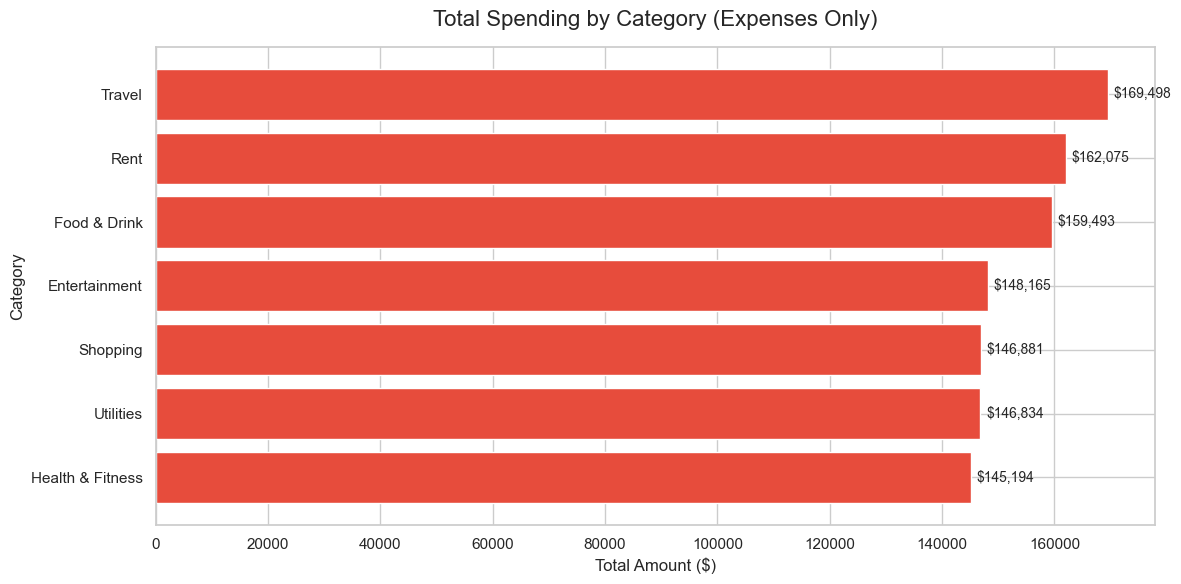

Chart 2 final version saved!


In [11]:
expenses_only = df[df['Type'] == 'Expense']
category_spend_fixed = expenses_only.groupby('Category')['Amount'].sum().reset_index()
category_spend_fixed.columns = ['Category', 'Total_Spent']
category_spend_fixed = category_spend_fixed.sort_values('Total_Spent', ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(category_spend_fixed['Category'], category_spend_fixed['Total_Spent'],
               color='#e74c3c')

ax.set_title('Total Spending by Category (Expenses Only)', fontsize=16, pad=15)
ax.set_xlabel('Total Amount ($)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

for bar in bars:
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart2_spending_by_category.png', dpi=150)
plt.show()
print("Chart 2 final version saved!")

## Chart 3: Monthly Income vs Expenses Trend

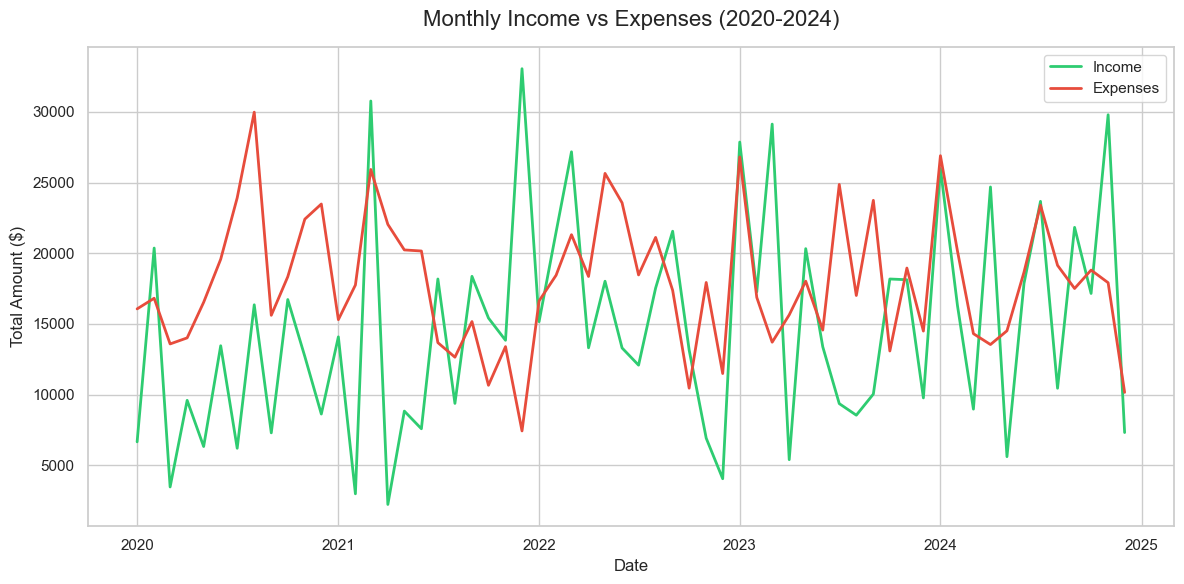

Chart 3 saved!


In [12]:
# Reload monthly trends with fixed data
monthly = df.groupby(['Year', 'Month', 'Month_Name', 'Type'])['Amount'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month'])

# Create a date column for plotting
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str))

# Split into income and expenses
income = monthly[monthly['Type'] == 'Income']
expenses = monthly[monthly['Type'] == 'Expense']

# Plot
fig, ax = plt.subplots()
ax.plot(income['Date'], income['Amount'], label='Income', color='#2ecc71', linewidth=2)
ax.plot(expenses['Date'], expenses['Amount'], label='Expenses', color='#e74c3c', linewidth=2)

ax.set_title('Monthly Income vs Expenses (2020-2024)', fontsize=16, pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Amount ($)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../data/chart3_monthly_trend.png', dpi=150)
plt.show()
print("Chart 3 saved!")

## Chart 4: Spending Heatmap by Day of Week and Category

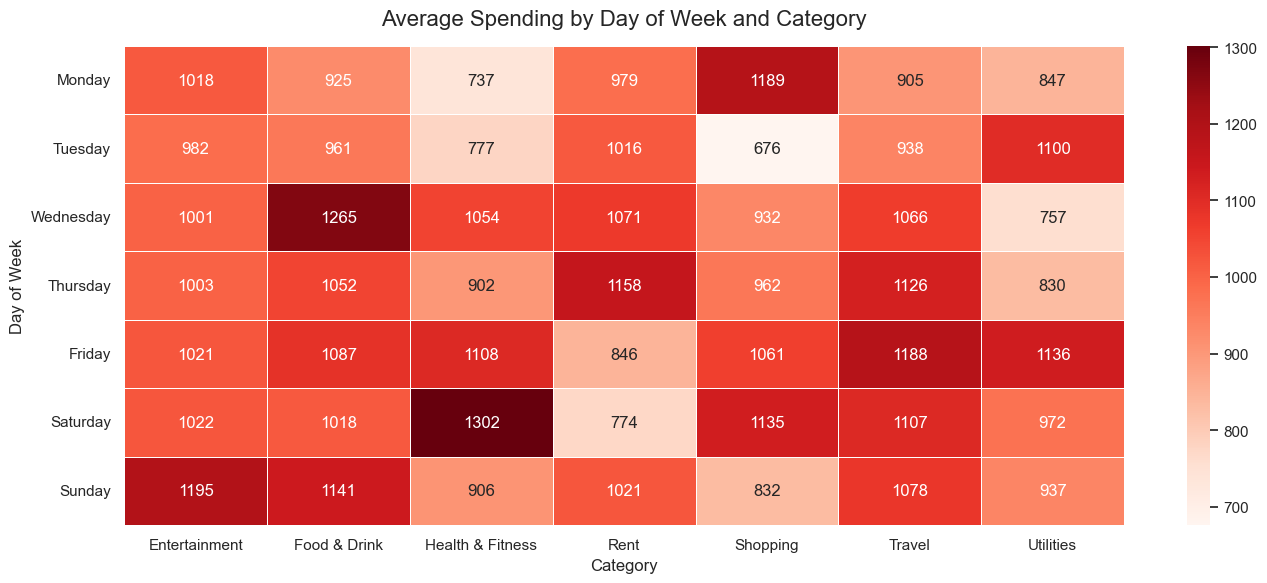

Chart 4 saved!


In [13]:
# Build pivot table of average spend by day of week and category
expenses_only = df[df['Type'] == 'Expense']

pivot = expenses_only.pivot_table(
    values='Amount',
    index='Day_of_Week',
    columns='Category',
    aggfunc='mean'
)

# Order days of week correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(day_order)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', ax=ax, linewidths=0.5)

ax.set_title('Average Spending by Day of Week and Category', fontsize=16, pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)

plt.tight_layout()
plt.savefig('../data/chart4_spending_heatmap.png', dpi=150)
plt.show()
print("Chart 4 saved!")

## Summary of Visualisations

- **Chart 1**: Total expenses ($1.2M) significantly exceed total income ($734K)
- **Chart 2**: Travel, Rent and Food & Drink are the top 3 expense categories
- **Chart 3**: Income is highly volatile month to month while expenses remain more consistent
- **Chart 4**: Food & Drink spending peaks mid-week and on Sundays. Health & Fitness spending is highest on Saturdays

**Data is ready for predictive modelling in Phase 4.**